### 1. Load the data

In [2]:
# Mount Google Drive (skip this cell if you uploaded the CSV directly to Colab's file browser instead)
from google.colab import drive
drive.mount('/content/drive')

# ---- EDIT THIS PATH to match where you placed the CSV in your Drive ----
DATA_PATH = "/content/drive/MyDrive/IT2011_Group_Project folder/data/raw/Lung Cancer.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (890000, 17)


,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


    ### 2. Why this technique is needed for this dataset
The columns you're given aren't always the most useful form for a model to
learn from. diagnosis_date and end_treatment_date are dates, and models can't
work with dates directly - but the gap between them, how long treatment lasted,
could actually be a meaningful signal for predicting survival. So instead of
just dropping these date columns, I turned them into a new feature:
treatment_duration_days.

The id column, on the other hand, is just a row identifier it doesn't carry
any real information about the patient, so it should be dropped entirely rather
than fed into a model.

Beyond creating new features, this step also checks whether any of the existing
features are redundant or highly correlated with each other (feature selection),
and demonstrates PCA, which is a way of compressing several features into fewer
dimensions while keeping as much of the original information as possible
(dimensionality reduction). This gives the group options to decide which version
of the data to actually use when building models in Step 3.

### 3. Implementation

In [3]:
fe = df.copy()

# 3a. Feature creation from dates: treatment duration in days
fe["diagnosis_date"] = pd.to_datetime(fe["diagnosis_date"])
fe["end_treatment_date"] = pd.to_datetime(fe["end_treatment_date"])
fe["treatment_duration_days"] = (fe["end_treatment_date"] - fe["diagnosis_date"]).dt.days
fe["diagnosis_year"] = fe["diagnosis_date"].dt.year

# 3b. Drop columns with no predictive value / already captured elsewhere
fe = fe.drop(columns=["id", "diagnosis_date", "end_treatment_date"])

print("New engineered columns added: treatment_duration_days, diagnosis_year")
fe[["treatment_duration_days", "diagnosis_year"]].describe()


New engineered columns added: treatment_duration_days, diagnosis_year


,treatment_duration_days,diagnosis_year
count,890000.000000,890000.000000
mean,458.087170,2018.917400
std,139.326048,2.913684
min,183.000000,2014.000000
25%,367.000000,2016.000000
50%,458.000000,2019.000000
75%,550.000000,2021.000000
max,730.000000,2024.000000


In [4]:
# 3c. Feature selection: correlation matrix on numeric + binary columns
num_cols = ["age", "bmi", "cholesterol_level", "hypertension", "asthma",
            "cirrhosis", "other_cancer", "treatment_duration_days", "survived"]
corr = fe[num_cols].corr()
print(corr["survived"].sort_values(ascending=False))


survived                   1.000000
cirrhosis                  0.001956
age                        0.001233
cholesterol_level          0.000157
hypertension               0.000059
bmi                        0.000007
treatment_duration_days   -0.000691
asthma                    -0.001809
other_cancer              -0.001972
Name: survived, dtype: float64


In [5]:
# 3d. Dimensionality reduction demo: PCA on the scaled numeric features
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_input = fe[["age", "bmi", "cholesterol_level", "treatment_duration_days"]]
pca_scaled = StandardScaler().fit_transform(pca_input)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(pca_scaled)

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum())


Explained variance ratio per component: [0.43677089 0.25004972]
Total variance captured by 2 components: 0.6868206071891807


### 4. EDA visualization

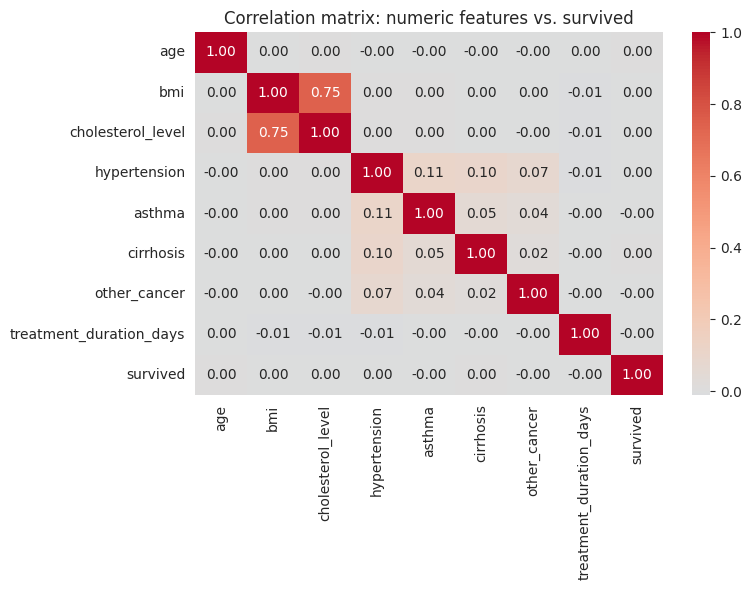

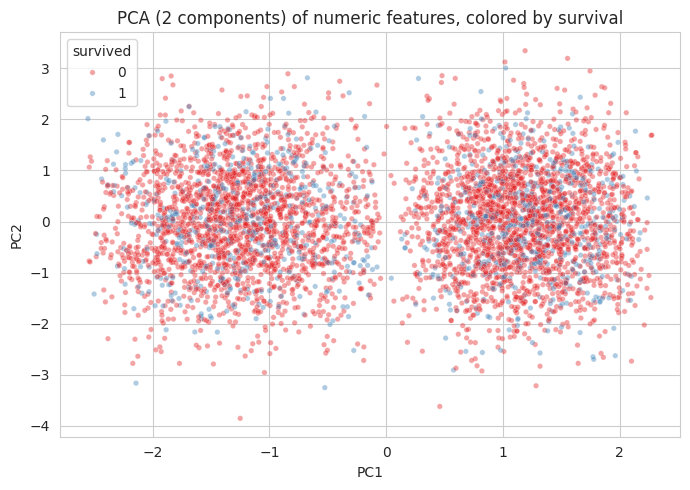

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix: numeric features vs. survived")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sample = pd.DataFrame(components, columns=["PC1", "PC2"])
sample["survived"] = fe["survived"].values
sns.scatterplot(data=sample.sample(5000, random_state=1), x="PC1", y="PC2",
                 hue="survived", alpha=0.4, palette="Set1", s=15)
plt.title("PCA (2 components) of numeric features, colored by survival")
plt.tight_layout()
plt.show()


### 5. Interpretation
Looking at the correlation heatmap, every numeric feature  age, bmi,
cholesterol, the comorbidity flags, and treatment duration  has a correlation
with survived that's extremely close to zero, all under 0.01. That's actually
an important finding for the whole group: none of the clinical features have
any detectable linear relationship with whether a patient survived. In real
clinical data you'd normally expect at least some features to show a meaningful
link to the outcome, so this strongly suggests the target variable in this
dataset was generated largely independently of the actual features.

The PCA scatter plot backs this up too  when I reduced the features down to
two dimensions, the survived and did-not-survive points are completely mixed
together with no visible separation between them.

This is worth being upfront about in the group report's Ethical Considerations
and Reflections sections. It basically means we shouldn't expect the models in
Step 3 and 4 to beat the majority class baseline of around 78% by much, and if
they don't, that's not a mistake in how the models were built  it's a genuine
property of this particular dataset.